In [2]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms
from torch.utils.data.sampler import SubsetRandomSampler

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# PREPROCESIRANJE KOJE TREBA DA BUDE UNUTAR TRENINGA
# NE POKRECI

import cv2
# Example normalization
def preprocess(image):
    # Resize to 227x227
    resized_image = cv2.resize(image, (227, 227))
    
    # Normalize pixel values
    normalized_image = resized_image / 255.0
    
    return normalized_image


In [4]:
import os
from PIL import Image
from torch.utils.data import Dataset

class QuickDraw0Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.class_to_idx = {}
        self.idx_to_class = {}  # novo: mapiranje indeks → naziv
        self.classes = []       # novo: lista imena klasa

        # Pronađi sve klase (nazive foldera)
        for idx, class_name in enumerate(sorted(os.listdir(root_dir))):
            class_path = os.path.join(root_dir, class_name)
            if os.path.isdir(class_path):
                self.class_to_idx[class_name] = idx
                self.idx_to_class[idx] = class_name
                self.classes.append(class_name)
                for fname in os.listdir(class_path):
                    if fname.endswith(('.png', '.jpg', '.jpeg')):
                        self.samples.append((os.path.join(class_path, fname), class_name))  # ovde dodaješ naziv klase

    def __len__(self):
        return len(self.samples)

    '''
    def __getitem__(self, idx):
        image_path, class_name = self.samples[idx]
        image = Image.open(image_path).convert('L')
        if self.transform:
            image = self.transform(image)
        return image, class_name  # vraćamo naziv klase kao label
    '''
    
    def __getitem__(self, idx):
        image_path, class_name = self.samples[idx]
        image = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = self.class_to_idx[class_name]  # vrati int umesto string
        return image, label

In [ ]:
import torchvision.transforms as transforms
direc = "balanced_chosen_50_images" # OVO SE POKRECE KAD JE PREBACENO SAMO 25 KLASA, NE SVIH 50
transform = transforms.Compose([
    transforms.Resize((227, 227)),  # ekvivalent cv2.resize
    transforms.ToTensor(),          # automatski skalira u [0, 1]
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],       # opcionalna normalizacija (centar na 0)
        std=[0.5, 0.5, 0.5]
    )
])

dataset = QuickDraw0Dataset(direc, transform=transform)

In [ ]:
# MOZDA BUDE POTREBNO, TRENUTNO NE SLUZI NICEMU
# NE POKRECI
from torch.utils.data import Subset


def create_subset(dataset, fraction=0.25):
    total_size = len(dataset)
    subset_size = int(total_size * fraction)
    
    indices = list(range(total_size))
    subset_indices = indices[:subset_size]
    
    return Subset(dataset, subset_indices)


subset_dataset = create_subset(dataset, fraction=0.25)

In [6]:
from torch.utils.data import Dataset, DataLoader, random_split

# Podeli dataset na trening (70%), validacioni (15%) i test set (15%)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

In [7]:
# Kreiraj DataLoader-e
batchsize = 64
train_loader = DataLoader(train_dataset, batch_size=batchsize, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batchsize, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batchsize, shuffle=False)

In [8]:
class AlexNet(nn.Module):
        def __init__(self, num_classes):
            super(AlexNet, self).__init__()
            self.layer1 = nn.Sequential(
                nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0),
                nn.BatchNorm2d(96),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 3, stride = 2))
            self.layer2 = nn.Sequential(
                nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2),
                nn.BatchNorm2d(256),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 3, stride = 2))
            self.layer3 = nn.Sequential(
                nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(384),
                nn.ReLU())
            self.layer4 = nn.Sequential(
                nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(384),
                nn.ReLU())
            self.layer5 = nn.Sequential(
                nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(256),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 3, stride = 2))
            self.fc = nn.Sequential(
                nn.Dropout(0.5),
                nn.Linear(9216, 4096),
                nn.ReLU())
            self.fc1 = nn.Sequential(
                nn.Dropout(0.5),
                nn.Linear(4096, 4096),
                nn.ReLU())
            self.fc2= nn.Sequential(
                nn.Linear(4096, num_classes))

        def forward(self, x):
            out = self.layer1(x)
            out = self.layer2(out)
            out = self.layer3(out)
            out = self.layer4(out)
            out = self.layer5(out)
            out = out.reshape(out.size(0), -1)
            out = self.fc(out)
            out = self.fc1(out)
            out = self.fc2(out)
            return out

In [ ]:
from torchsummary import summary
# Instantiate model
alexnet = AlexNet(25)
# Get complete summary of AlexNet
summary(alexnet, (3, 227, 227), batch_size=64)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [128, 96, 55, 55]          34,944
       BatchNorm2d-2          [128, 96, 55, 55]             192
              ReLU-3          [128, 96, 55, 55]               0
         MaxPool2d-4          [128, 96, 27, 27]               0
            Conv2d-5         [128, 256, 27, 27]         614,656
       BatchNorm2d-6         [128, 256, 27, 27]             512
              ReLU-7         [128, 256, 27, 27]               0
         MaxPool2d-8         [128, 256, 13, 13]               0
            Conv2d-9         [128, 384, 13, 13]         885,120
      BatchNorm2d-10         [128, 384, 13, 13]             768
             ReLU-11         [128, 384, 13, 13]               0
           Conv2d-12         [128, 384, 13, 13]       1,327,488
      BatchNorm2d-13         [128, 384, 13, 13]             768
             ReLU-14         [128, 384,

In [9]:
print(device)

cpu


In [ ]:
import torch.optim as optim
train_loss = []
train_accuracy = []
val_losslist = []
val_accuracy = []

#os.makedirs("saved_models_top3_vgg_0", exist_ok=True)
alexnet.load_state_dict(torch.load("saved_models/alexnet2/model_epoch_1.pth"))
alexnet.to(device)
start = 1
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(alexnet.parameters(), lr=0.001, momentum=0.9)
# Training loop
for epoch in range(start, 20):  # Run for 20 epochs
    alexnet.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = alexnet(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
        train_accuracy.append(100 * correct / total)
        train_loss.append(running_loss/len(train_loader))
    
    print(f'Epoch [{epoch+1}/10], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {100 * correct / total:.2f}%')
    model_path = f"saved_models/alexnet25.0/model_epoch_{epoch+1}.pth"
    torch.save(alexnet.state_dict(), model_path)

    alexnet.eval()
    val_loss = 0.0
    with torch.no_grad():
        for input_image, target_image in val_loader:
            input_image = input_image.to(device)
            target_image = target_image.to(device)
            outputs = alexnet(input_image)
            loss = criterion(outputs, target_image)
            val_loss += loss.item()
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    val_accuracy.append(100 * correct / total)
    val_losslist.append(val_loss/len(val_loader))

    print(f"Validation Loss: {val_loss/len(val_loader)}, Accuracy: {100 * correct / total:.2f}%")

Epoch [2/10], Loss: 0.5732, Accuracy: 82.33%
Validation Loss: 0.4820096248413547, Accuracy: 82.87%
Epoch [3/10], Loss: 0.4872, Accuracy: 84.84%
Validation Loss: 0.4553461776951612, Accuracy: 84.98%
Epoch [4/10], Loss: 0.4410, Accuracy: 86.41%
Validation Loss: 0.43999939645498487, Accuracy: 87.44%
Epoch [5/10], Loss: 0.4061, Accuracy: 87.41%
Validation Loss: 0.4341088947603258, Accuracy: 87.70%
Epoch [6/10], Loss: 0.3771, Accuracy: 88.24%
Validation Loss: 0.41957505489304914, Accuracy: 87.27%
Epoch [7/10], Loss: 0.3517, Accuracy: 88.85%
Validation Loss: 0.4257551815550206, Accuracy: 88.64%
Epoch [8/10], Loss: 0.3333, Accuracy: 89.55%
Validation Loss: 0.4221363990741261, Accuracy: 88.94%
Epoch [9/10], Loss: 0.3115, Accuracy: 90.16%
Validation Loss: 0.3830572383131011, Accuracy: 91.16%
Epoch [10/10], Loss: 0.2927, Accuracy: 90.63%
Validation Loss: 0.40964353804366066, Accuracy: 89.85%


In [ ]:
import torch
from torchvision import models
from sklearn.metrics import classification_report
from tqdm import tqdm  # za lepši prikaz progres bara (opciono)
'''
# 1. Učitaj model i prebaci na eval mod
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Pretpostavka: imaš 10 klasa (prilagodi ako je drugačije)
num_classes = 10

# Inicijalizuj model i zameni poslednji sloj
model = models.vgg16(pretrained=False)
model.classifier[6] = torch.nn.Linear(4096, num_classes)
'''

# Učitaj težine
alexnet.load_state_dict(torch.load('saved_models/alexnet25.0/model_epoch_10.pth', map_location=device))
alexnet = alexnet.to(device)
alexnet.eval()

# 2. Evaluacija
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images, labels = images.to(device), labels.to(device)
        outputs = alexnet(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# 3. Izračunaj metrike
print("=== Izveštaj klasifikacije ===")
print(classification_report(y_true, y_pred, digits=4))

100%|██████████| 118/118 [02:33<00:00,  1.30s/it]

=== Izveštaj klasifikacije ===
              precision    recall  f1-score   support

           0     0.9614    0.9307    0.9458       750
           1     0.7966    0.9454    0.8647       696
           2     0.7595    0.7469    0.7531       723
           3     0.8787    0.7109    0.7859       754
           4     0.9808    0.9191    0.9490       779
           5     0.9057    0.9384    0.9218       747
           6     0.8377    0.8592    0.8483       781
           7     0.9736    0.8701    0.9189       762
           8     0.9766    0.9174    0.9461       775
           9     0.7273    0.9059    0.8068       733

    accuracy                         0.8744      7500
   macro avg     0.8798    0.8744    0.8740      7500
weighted avg     0.8818    0.8744    0.8751      7500



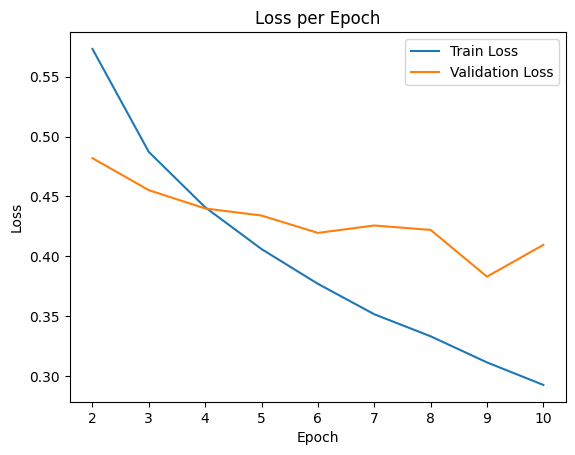

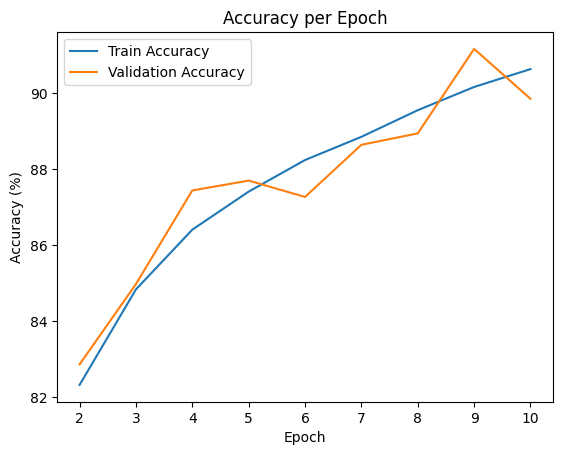

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, 11))

plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_losslist, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss per Epoch")
plt.show()

plt.plot(epochs, train_accuracy, label="Train Accuracy")
plt.plot(epochs, val_accuracy, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Accuracy per Epoch")
plt.show()